In [2]:
import requests
import pandas as pd
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline

In [3]:
import os 
os.getcwd()
os.chdir('../')
from utils import build_df_sparse, build_df

#### Plot rolling means and variances

If the rolling statistics exhibit a clear trend and show varying variances (increasing or decreasing amplitude), the series is very likely ***not*** to be stationary.

In [4]:
df = build_df()

In [5]:
df['z_data'] = (df['trips_count'] - df.trips_count.rolling(window=12).mean()) / df.trips_count.rolling(window=12).std()
df['zp_data'] = df['z_data'] - df['z_data'].shift(12)


In [13]:
def plot_rolling(df):
    fig, ax = plt.subplots(3,figsize=(12, 9))
    ax[0].plot(df.index, df.trips_count, label='raw number of trips')
    ax[0].plot(df.trips_count.rolling(window=12).mean(), label="rolling mean")
    ax[0].plot(df.trips_count.rolling(window=12).std(), label="rolling std (x10)")
    ax[0].legend()

    ax[1].plot(df.index, df.z_data, label="de-trended data")
    ax[1].plot(df.z_data.rolling(window=12).mean(), label="rolling mean")
    ax[1].plot(df.z_data.rolling(window=12).std(), label="rolling std (x10)")
    ax[1].legend()

    ax[2].plot(df.index, df.zp_data, label="12 lag differenced de-trended data")
    ax[2].plot(df.zp_data.rolling(window=12).mean(), label="rolling mean")
    ax[2].plot(df.zp_data.rolling(window=12).std(), label="rolling std (x10)")
    ax[2].legend()

    plt.tight_layout()
    fig.autofmt_xdate()

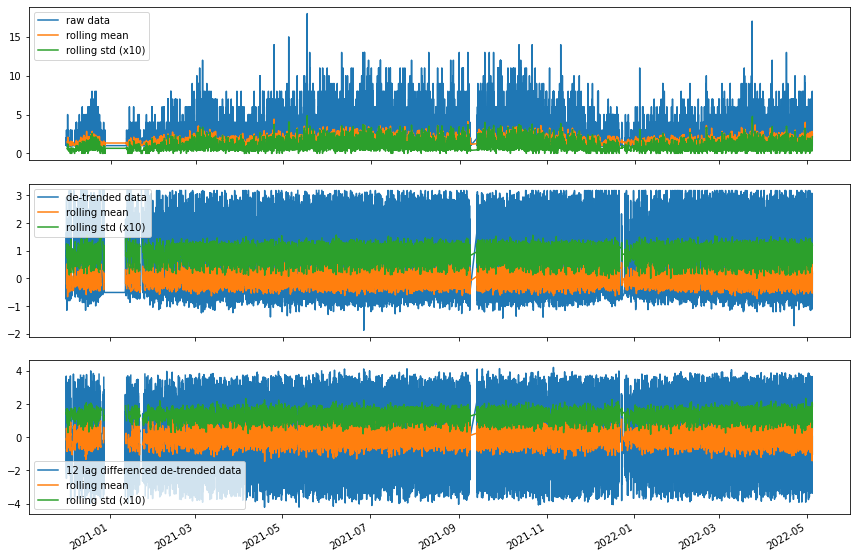

In [6]:
plot_rolling(df)

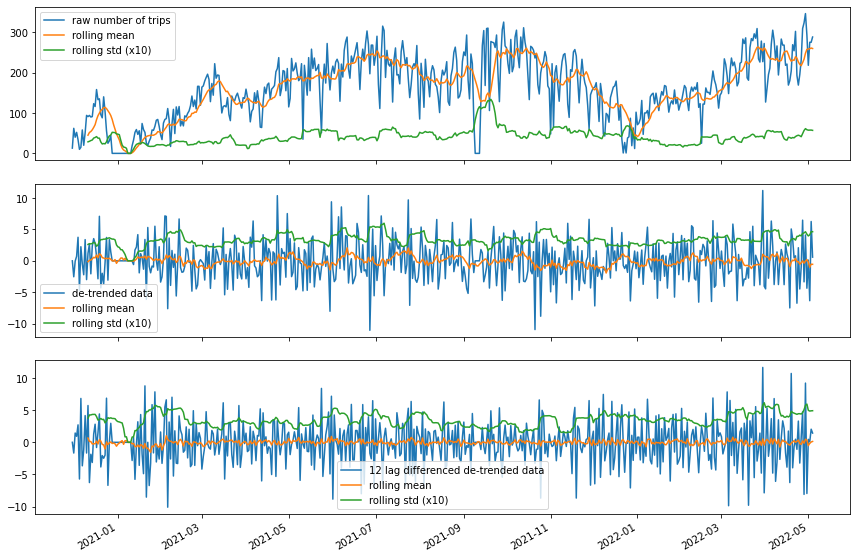

In [14]:
# sum trips count daily
df_daily = df.reset_index()
df_daily = df_daily.groupby([pd.Grouper(key='trip_start', freq='D')]).sum()
plot_rolling(df_daily)

#### Testing timeserie stationarity using Augmented Dickey-Fuller Test

In [18]:
from statsmodels.tsa.stattools import adfuller

print(" > Is the data stationary ?")
dftest = adfuller(df.trips_count, autolag='AIC')
print("Test statistic = {:.3f}".format(dftest[0]))
print("P-value = {:.3f}".format(dftest[1]))
print("Critical values :")
for k, v in dftest[4].items():
    print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))
    
print("\n > Is the de-trended data stationary ?")
dftest = adfuller(df.z_data.dropna(), autolag='AIC')
print("Test statistic = {:.3f}".format(dftest[0]))
print("P-value = {:.3f}".format(dftest[1]))
print("Critical values :")
for k, v in dftest[4].items():
    print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))
    
print("\n > Is the 12-lag differenced de-trended data stationary ?")
dftest = adfuller(df.zp_data.dropna(), autolag='AIC')
print("Test statistic = {:.3f}".format(dftest[0]))
print("P-value = {:.3f}".format(dftest[1]))
print("Critical values :")
for k, v in dftest[4].items():
    print("\t{}: {} - The data is {} stationary with {}% confidence".format(k, v, "not" if v<dftest[0] else "", 100-int(k[:-1])))

 > Is the data stationary ?
Test statistic = -27.433
P-value = 0.000
Critical values :
	1%: -3.430482676822653 - The data is  stationary with 99% confidence
	5%: -2.8615986404121783 - The data is  stationary with 95% confidence
	10%: -2.5668012123552293 - The data is  stationary with 90% confidence

 > Is the de-trended data stationary ?
Test statistic = -41.878
P-value = 0.000
Critical values :
	1%: -3.4304829925243334 - The data is  stationary with 99% confidence
	5%: -2.8615987799426663 - The data is  stationary with 95% confidence
	10%: -2.5668012866232455 - The data is  stationary with 90% confidence

 > Is the 12-lag differenced de-trended data stationary ?
Test statistic = -50.231
P-value = 0.000
Critical values :
	1%: -3.4304832363960047 - The data is  stationary with 99% confidence
	5%: -2.861598887726477 - The data is  stationary with 95% confidence
	10%: -2.5668013439934314 - The data is  stationary with 90% confidence


c:\Users\luisa\Anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


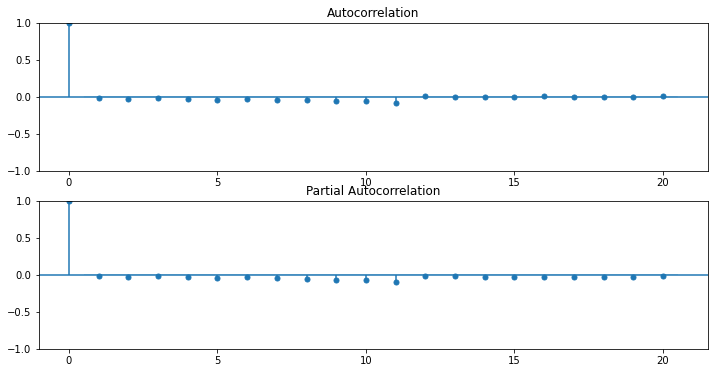

In [19]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# from the autocorrelation plot one can say there is nearly no correlation between trips_count at lag 0 and trips_count in the following lags
# The general rule is that, if the series has positive autocorrelations out to a high number of lags, then it probably needs a higher order of differencing, 
# in order to be stationary and be fed to an ARIMA model. If autocorrelations are all small and patternless, then the series does not need a higher order of differencing. 
fig, ax = plt.subplots(2, figsize=(12,6))
ax[0] = plot_acf(df.z_data.dropna(), ax=ax[0], lags=20)
ax[1] = plot_pacf(df.z_data.dropna(), ax=ax[1], lags=20)

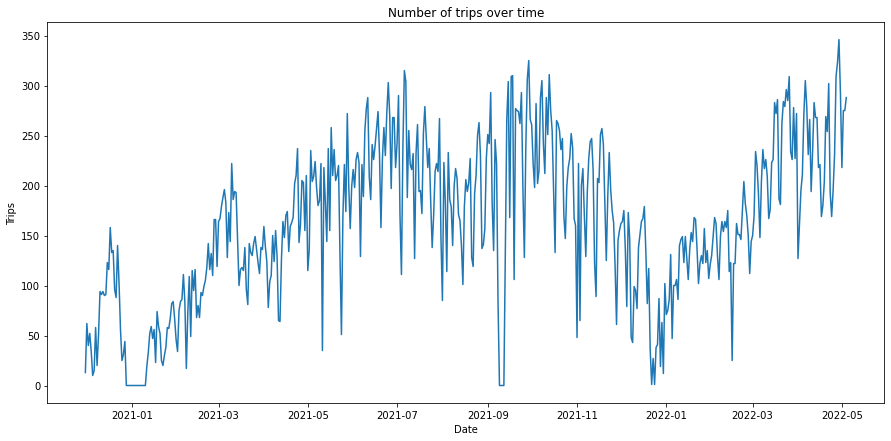

In [9]:
df = df.resample("D").sum()

plt.figure(figsize=(15,7))
plt.title("Number of trips over time", color='black')
plt.xlabel('Date')
plt.ylabel('Trips')
plt.plot(df['trips_count'])
plt.show()